# K06_01_Regularisierung_und_Overfitting_mit_Moons

Update am 24. Mai 2026

Dozentenversion

## Lernziele

Nach diesem Notebook können Sie:
- den Begriff **Overfitting** an einem Entscheidungsbaum erklären
- **Regularisierung** durch `min_samples_leaf` demonstrieren
- den Unterschied zwischen Train- und Test-Score interpretieren
- erklären, warum ein Modell auf Trainingsdaten besser abschneidet als auf Testdaten

---

**Kern-Idee dieses Notebooks:**

```
Baum 1 (unreguliert): lernt jedes Detail der Trainingsdaten
                      -> perfekter Train-Score, schlechter Test-Score
                      -> Overfitting

Baum 2 (reguliert):   lernt nur grobe Muster
                      -> niedrigerer Train-Score, besserer Test-Score
                      -> bessere Generalisierung
```


# Moons Datensatz erstellen und plotten

Trainingsdaten: 105 Punkte
Testdaten:      45 Punkte


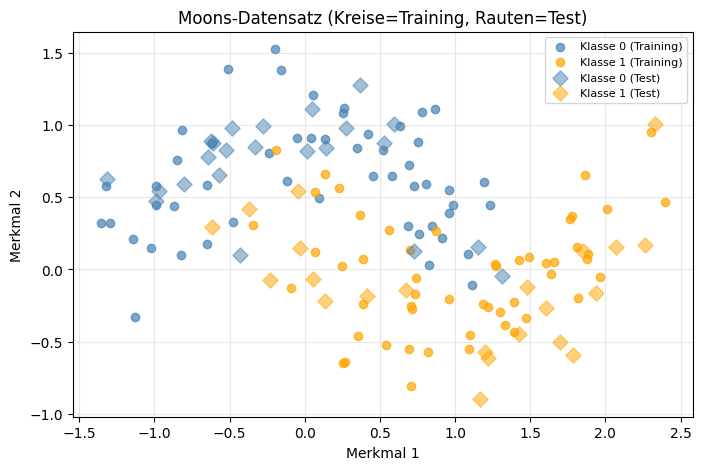

In [5]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Moons-Datensatz mit 150 Punkten und moderatem Rauschen
X, y = make_moons(n_samples=150, noise=0.25, random_state=42)

# Train/Test-Split: 70% Training, 30% Test
# stratify=y: beide Klassen gleichmaessig verteilt
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Trainingsdaten: {len(X_train)} Punkte")
print(f"Testdaten:      {len(X_test)} Punkte")

# Alle Daten visualisieren
plt.figure(figsize=(8, 5))
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1],
            color='steelblue', marker='o', label='Klasse 0 (Training)', alpha=0.7)
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1],
            color='orange', marker='o', label='Klasse 1 (Training)', alpha=0.7)
plt.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1],
            color='steelblue', marker='D', label='Klasse 0 (Test)', alpha=0.5, s=60)
plt.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1],
            color='orange', marker='D', label='Klasse 1 (Test)', alpha=0.5, s=60)
plt.title('Moons-Datensatz (Kreise=Training, Rauten=Test)')
plt.xlabel('Merkmal 1')
plt.ylabel('Merkmal 2')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.show()


# Entscheidungsbaum Modell initialisieren und zwei Varianten trainieren

In [6]:
from sklearn.tree import DecisionTreeClassifier

# Baum 1: unreguliert -- wächst so tief wie nötig
# min_samples_leaf=1 ist der Standardwert: jedes Blatt darf 1 Punkt enthalten
tree_clf1 = DecisionTreeClassifier(min_samples_leaf=1, random_state=42)
tree_clf1.fit(X_train, y_train)   # nur Trainingsdaten!

# Baum 2: reguliert -- jedes Blatt muss mindestens 5 Punkte enthalten
tree_clf2 = DecisionTreeClassifier(min_samples_leaf=5, random_state=42)
tree_clf2.fit(X_train, y_train)   # nur Trainingsdaten!

print(f"Baum 1 (unreguliert): Tiefe = {tree_clf1.get_depth()}, "
      f"Blaetter = {tree_clf1.get_n_leaves()}")
print(f"Baum 2 (reguliert):   Tiefe = {tree_clf2.get_depth()}, "
      f"Blaetter = {tree_clf2.get_n_leaves()}")
print()
print("Beobachtung: Baum 1 ist tiefer und hat mehr Blaetter")
print("-> er hat die Trainingsdaten feiner aufgeteilt -> Overfitting-Risiko")


Baum 1 (unreguliert): Tiefe = 7, Blaetter = 19
Baum 2 (reguliert):   Tiefe = 5, Blaetter = 12

Beobachtung: Baum 1 ist tiefer und hat mehr Blaetter
-> er hat die Trainingsdaten feiner aufgeteilt -> Overfitting-Risiko


# Entscheidungsgrenzen der Bäume visualisieren

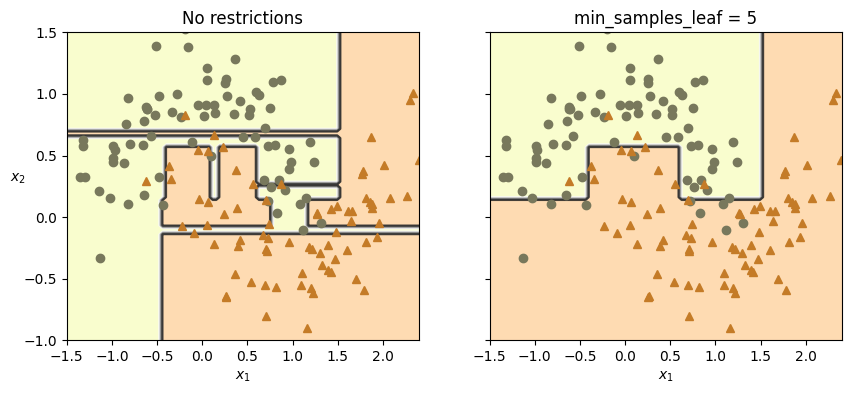

In [3]:
import numpy as np

def plot_decision_boundary(clf, X, y, axes, cmap):
    x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                         np.linspace(axes[2], axes[3], 100))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=cmap)
    plt.contour(x1, x2, y_pred, cmap="Greys", alpha=0.8)
    colors = {"Wistia": ["#78785c", "#c47b27"], "Pastel1": ["red", "blue"]}
    markers = ("o", "^")
    for idx in (0, 1):
        plt.plot(X[:, 0][y == idx], X[:, 1][y == idx],
                 color=colors[cmap][idx], marker=markers[idx], linestyle="none")
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation=0)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf1, X, y,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title("No restrictions")
plt.sca(axes[1])
plot_decision_boundary(tree_clf2, X, y,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title(f"min_samples_leaf = {tree_clf2.min_samples_leaf}")
plt.ylabel("")
plt.show()

## 4. Evaluation: Train-Score vs. Test-Score

Jetzt sehen wir, ob sich Overfitting im Test-Score niederschlägt.

- **Train-Score**: Wie gut funktioniert das Modell auf den Daten, auf denen es gelernt hat?
- **Test-Score**: Wie gut funktioniert es auf neuen, ungesehenen Daten?

> **Merkmal von Overfitting:** Grosser Abstand zwischen Train- und Test-Score.
> Der unregulierte Baum lernt die Trainingsdaten fast perfekt auswendig --
> er versagt aber auf neuen Daten.


In [4]:
# Evaluation auf Testdaten (X_test wurde beim Training NICHT gesehen)
score1_test = tree_clf1.score(X_test, y_test)
score2_test = tree_clf2.score(X_test, y_test)

# Zum Vergleich: Score auf Trainingsdaten
score1_train = tree_clf1.score(X_train, y_train)
score2_train = tree_clf2.score(X_train, y_train)

print("Vergleich: Train-Score vs. Test-Score")
print("-" * 50)
print(f"Baum 1 (unreguliert): Train={score1_train:.3f}  Test={score1_test:.3f}  "
      f"Differenz={score1_train-score1_test:.3f}")
print(f"Baum 2 (reguliert):   Train={score2_train:.3f}  Test={score2_test:.3f}  "
      f"Differenz={score2_train-score2_test:.3f}")
print()
print("Interpretation:")
if score1_train - score1_test > score2_train - score2_test:
    print("-> Baum 1 zeigt staerkere Overfitting-Zeichen (groessere Train-Test-Differenz)")
print("-> Baum 2 generalisiert besser auf neue Daten")
print()
print("Merksatz: Ein hoher Train-Score bedeutet nicht automatisch ein gutes Modell.")
print("          Entscheidend ist der Test-Score!")


Vergleich: Train-Score vs. Test-Score
--------------------------------------------------
Baum 1 (unreguliert): Train=1.000  Test=0.889  Differenz=0.111
Baum 2 (reguliert):   Train=0.914  Test=0.911  Differenz=0.003

Interpretation:
-> Baum 1 zeigt staerkere Overfitting-Zeichen (groessere Train-Test-Differenz)
-> Baum 2 generalisiert besser auf neue Daten

Merksatz: Ein hoher Train-Score bedeutet nicht automatisch ein gutes Modell.
          Entscheidend ist der Test-Score!


## 5. Zusammenfassung

### Was wir gelernt haben

| | Baum 1 (unreguliert) | Baum 2 (reguliert) |
|---|---|---|
| `min_samples_leaf` | 1 (Standard) | 5 |
| Baumtiefe | gross | kleiner |
| Train-Score | sehr hoch | etwas niedriger |
| Test-Score | niedriger | hoeher |
| Diagnose | Overfitting | besser generalisiert |

### Merksaetze

- **Overfitting**: Das Modell lernt die Trainingsdaten auswendig statt allgemeine Muster
- **Regularisierung**: Wir begrenzen die Modellkomplexität, damit es besser generalisiert
- **`min_samples_leaf`**: Je grösser, desto robuster -- aber auch desto unflexibler
- **Train-Test-Differenz**: Kleiner Abstand = gute Generalisierung; grosser Abstand = Overfitting
